In this notebook, we'll calculate the level of agreement between elements of a class of digits. There are 10 classes of digits 0-9. Let $a$ be an element of class $A$ and $b$ be an element of class $B$. For current purposes, the level of agreement between $a$ and $b$ is given by

$$
    \frac{||a*b||_\infty}{\sqrt{||a||_F||b||_F}.
$$

In [11]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import morphology as morph
from scipy.signal import fftconvolve, correlate
import numpy.linalg as LA

In [2]:
# These libraries are used to unzip and read in the binary data.
import pickle
import gzip

def load_data():
    """ Return a tuple containing (training_data, validation_data,
    test_data). 
    
    In particular, `training_data` is a list containing 50,000
    2-tuples `(x, y)`.  
    `x` is a 784-dimensional numpy.ndarray
    containing the input image.  
    
    `y` is a 10-dimensional
    numpy.ndarray representing the unit vector corresponding to the
    correct digit for `x`.
    
    `validation_data` and `test_data` are lists containing 10,000
    2-tuples `(x, y)`. In each case, `x` is a 784-dimensional
    numpy.ndarry containing the input image, and `y` is the
    corresponding classification, i.e., the digit values (integers)
    corresponding to `x`.
    
    Obviously, this means we're using slightly different formats for
    the training data and the validation / test data.  These formats
    turn out to be the most convenient for use in our neural network
    code.
    """
    
    # Unzip and load in the binary data.
    with gzip.open('mnist.pkl.gz', 'rb') as binary_file:
        tr_d, va_d, te_d = pickle.load(binary_file, encoding="latin1")
        
    train_data = [image.reshape((28,28)) for image in tr_d[0]]
    train_labels = tr_d[1]
    
    valid_data = [image.reshape((28,28)) for image in va_d[0]]
    valid_labels = va_d[1]
    
    test_data = [image.reshape((28,28)) for image in te_d[0]]
    test_labels = te_d[1]
    
    return pd.DataFrame(zip(train_data, train_labels), columns = ['image','label']), pd.DataFrame(zip(valid_data,valid_labels), columns = ['image','label']), pd.DataFrame(zip(test_data, test_labels), columns = ['image','label'])

# Extract only the image data from the DataFrames
def extract_image(frame, digit):
    """ This function takes in a dataset containing images. 
        The set is converted to a DataFrame, and the images
        corresponding to the given digit are extracted.
        
        An array containing images of the given digit is
        returned.
    """
        
    ims = frame[frame['label'] == digit]
    
    # Now ims only contains labels matching the digit, so we can drop the label column.
    ims.drop('label', axis = 1, inplace = True)
    
    return np.array(ims['image'])

def display_lengths(data):
    """ Display the total length of each subset of digits. 
    
        Used for checking that the conversion worked as expected.
    """
    
    for i in range(10):
        print('{} examples of digit {}'.format(len(data[i]), i))
    print('{} examples in total\n'.format(sum(len(data[i]) for i in range(10))))
    return None

train, valid, test = load_data()
data = pd.concat([train,valid,test])
data

,image,label
0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",5
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",4
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9
...,...,...
9995,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",2
9996,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3
9997,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",4
9998,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",5


In [3]:
images = [extract_image(data, i) for i in range(10)]
display_lengths(images)

6903 examples of digit 0
7877 examples of digit 1
6990 examples of digit 2
7141 examples of digit 3
6824 examples of digit 4
6313 examples of digit 5
6876 examples of digit 6
7293 examples of digit 7
6825 examples of digit 8
6958 examples of digit 9
70000 examples in total



C:\Users\matthew.adams\AppData\Local\Continuum\anaconda3\lib\site-packages\pandas\core\frame.py:4102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [4]:
# Finally, save each digit/array of digits pair as a dictionary.

digits = {key:value for key,value in zip(range(10), images)}

In [5]:
zeros = digits[0]

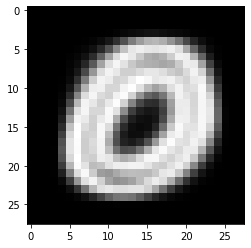

In [6]:
# Variance of the zero digits
plt.imshow(zeros.var(), cmap = 'gray');

Now we'll calculate the pairwise agreement with a subset of 500 examples of zeros.

In [9]:
zero_sample = zeros[:10]

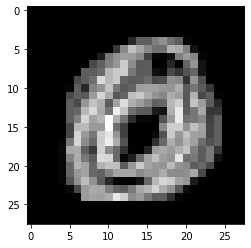

In [10]:
# I want to see if the variance of our sample is similar to that of the full set
plt.imshow(zero_sample.var(), cmap = 'gray');

In [19]:
# Calculate the agreement of elements of zero_sample with all other elements.
def calculate_agreement(sample):
    """ Calculate the level of agreement between every 
        element in sample and all other elements in sample.
        
        The level of agreement is
        ||A (star) B||/sqrt(||A(star)A||)sqrt(||B(star)B||)
    """
    
    correlations = [LA.norm(correlate(A,B,method='fft',mode='same'),ord='fro')/(np.sqrt(LA.norm(correlate(A,A,method='fft',mode='same'),ord='fro'))*np.sqrt(LA.norm(correlate(B,B,method='fft',mode='same'),ord='fro'))) for A in sample for B in sample]
    return correlations
    

In [23]:
corr = [LA.norm(correlate(A,B,method='fft',mode='same'),ord='fro')/(np.sqrt(LA.norm(correlate(A,A,method='fft',mode='same'),ord='fro'))*np.sqrt(LA.norm(correlate(B,B,method='fft',mode='same'),ord='fro'))) for A in zero_sample for B in zero_sample]

In [20]:
corr = calculate_agreement(zero_sample)

In [24]:
agreement_chart = pd.DataFrame(np.array(corr).reshape(10,10))
agreement_chart

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.993721,0.960173,0.978872,0.980506,0.959038,0.986383,0.918196,0.965397,0.991055
1,0.994645,1.000000,0.964419,0.980308,0.985368,0.963465,0.991123,0.918311,0.966834,0.989162
2,0.957532,0.961617,1.000000,0.990956,0.949433,0.941471,0.972721,0.894246,0.979372,0.981777
3,0.976299,0.977610,0.991219,1.000000,0.964608,0.956129,0.987032,0.910357,0.980898,0.994035
4,0.980767,0.983494,0.951452,0.966042,1.000000,0.981256,0.984788,0.929981,0.972217,0.976923
5,0.956669,0.960511,0.942649,0.955545,0.979787,1.000000,0.966659,0.954576,0.970753,0.959909
6,0.985429,0.989116,0.974116,0.987370,0.985222,0.967432,1.000000,0.924197,0.979648,0.989746
7,0.919479,0.921851,0.897476,0.912632,0.932634,0.953895,0.924671,1.000000,0.924113,0.923421
8,0.962773,0.963887,0.979379,0.980518,0.970619,0.969475,0.978358,0.923063,1.000000,0.980823
9,0.989857,0.986905,0.982534,0.994325,0.975966,0.960344,0.988901,0.920499,0.981571,1.000000


I think that using correlations is causing some trouble with our norms in that we're getting higher than expected agreement. In the next few cells, I'll just use the vector product instead of cross-correlations.

In [43]:
agree = [LA.norm(A*B,np.inf)/(np.sqrt(LA.norm(A*A,np.inf))*np.sqrt(LA.norm(B*B,np.inf))) for A in zero_sample for B in zero_sample]

In [44]:
agree_chart = pd.DataFrame(np.array(agree).reshape(10,10))
agree_chart

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.978261,0.902005,0.929933,0.915456,0.865859,0.844644,0.389564,0.862914,0.796715
1,0.978261,1.000000,0.920419,0.941028,0.901705,0.857790,0.925059,0.479714,0.908036,0.763953
2,0.902005,0.920419,1.000000,0.904496,0.842914,0.812381,0.797608,0.598572,0.887541,0.901594
3,0.929933,0.941028,0.904496,1.000000,0.832431,0.831261,0.858898,0.415860,0.870938,0.856537
4,0.915456,0.901705,0.842914,0.832431,1.000000,0.959190,0.834612,0.675274,0.898892,0.919115
5,0.865859,0.857790,0.812381,0.831261,0.959190,1.000000,0.829109,0.863597,0.897366,0.715357
6,0.844644,0.925059,0.797608,0.858898,0.834612,0.829109,1.000000,0.470447,0.870239,0.798561
7,0.389564,0.479714,0.598572,0.415860,0.675274,0.863597,0.470447,1.000000,0.791793,0.642079
8,0.862914,0.908036,0.887541,0.870938,0.898892,0.897366,0.870239,0.791793,1.000000,0.794608
9,0.796715,0.763953,0.901594,0.856537,0.919115,0.715357,0.798561,0.642079,0.794608,1.000000


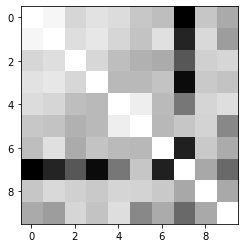

In [53]:
plt.imshow(agree_chart,cmap='gray');

From the chart above, it looks like sample elements 0 and 7 are very different. Let's take a look.

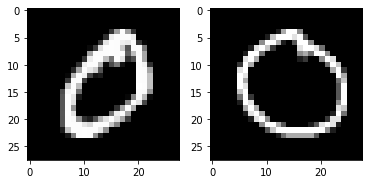

In [48]:
fig, ax = plt.subplots(1,2)

ax[0].imshow(zero_sample[0],cmap='gray')
ax[1].imshow(zero_sample[7],cmap='gray');

Ok, now let's take a much larger sample, 500 elements.

In [49]:
zero_sample = zeros[:500]

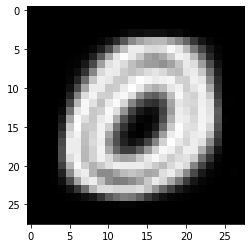

In [52]:
plt.imshow(zero_sample.var(), cmap='gray');

In [58]:
agree = [LA.norm(A*B,2)/(np.sqrt(LA.norm(A*A,2))*np.sqrt(LA.norm(B*B,2))) for A in zero_sample for B in zero_sample]

In [59]:
agree_chart = pd.DataFrame(np.array(agree).reshape(500,500))
agree_chart

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.000000,0.902319,0.764127,0.803047,0.812553,0.750700,0.784176,0.490334,0.720887,0.783204,...,0.857252,0.811086,0.856938,0.788135,0.825468,0.877948,0.652460,0.873461,0.761434,0.821820
1,0.902319,1.000000,0.742472,0.794372,0.831266,0.731726,0.828806,0.440686,0.736413,0.799193,...,0.812922,0.780219,0.826373,0.752336,0.799822,0.875528,0.637266,0.852286,0.790572,0.869751
2,0.764127,0.742472,1.000000,0.894989,0.702946,0.656360,0.756255,0.479732,0.819048,0.843467,...,0.701247,0.629360,0.739452,0.619151,0.721553,0.745882,0.572001,0.745642,0.711342,0.722985
3,0.803047,0.794372,0.894989,1.000000,0.690981,0.653765,0.774242,0.467160,0.835146,0.851820,...,0.723582,0.601962,0.746211,0.671716,0.689885,0.836560,0.584081,0.783027,0.811841,0.737980
4,0.812553,0.831266,0.702946,0.690981,1.000000,0.815815,0.823969,0.564527,0.793193,0.806161,...,0.814204,0.870657,0.804145,0.837341,0.838811,0.775146,0.712359,0.805600,0.703748,0.815740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.877948,0.875528,0.745882,0.836560,0.775146,0.725073,0.750886,0.441555,0.689271,0.740441,...,0.806953,0.734832,0.836233,0.733118,0.751089,1.000000,0.701866,0.899604,0.884698,0.815346
496,0.652460,0.637266,0.572001,0.584081,0.712359,0.600585,0.601444,0.593620,0.609240,0.702501,...,0.687955,0.634882,0.666083,0.687284,0.690953,0.701866,1.000000,0.620714,0.621242,0.571334
497,0.873461,0.852286,0.745642,0.783027,0.805600,0.745038,0.809018,0.435580,0.713563,0.731274,...,0.839372,0.825218,0.888133,0.782491,0.832728,0.899604,0.620714,1.000000,0.846639,0.889746
498,0.761434,0.790572,0.711342,0.811841,0.703748,0.682004,0.717943,0.406431,0.644977,0.668544,...,0.734691,0.722150,0.759918,0.717475,0.685004,0.884698,0.621242,0.846639,1.000000,0.786814


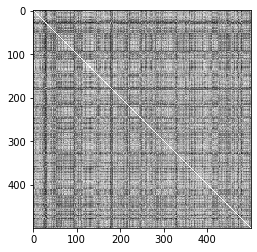

In [60]:
plt.imshow(agree_chart,cmap='gray');

Now I need to sort out the rows so that they fall off from 1 towards zero as you move away from the main diagonal.